In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df.drop(columns=[
    'show_id',
    'title',
    'director',
    'cast',
    'description'
], inplace=True, errors='ignore')

In [13]:
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])
df['date_added'] = df['date_added'].fillna("Unknown")

In [14]:
df['duration'] = df['duration'].str.extract('(\d+)')
df['duration'] = df['duration'].astype(int)

In [15]:
le = LabelEncoder()

for col in ['type', 'country', 'rating', 'listed_in']:
    df[col] = le.fit_transform(df[col])

In [16]:
X = df[['release_year', 'duration', 'type', 'rating']]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

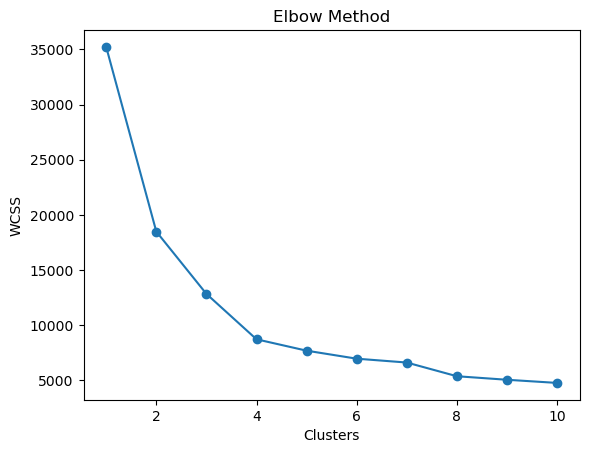

In [19]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.4812960908866949


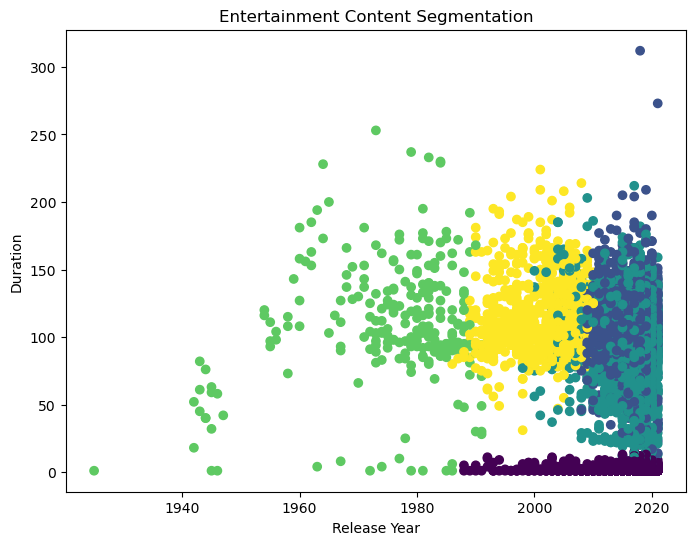

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['release_year'],
    df['duration'],
    c=df['Cluster']
)

plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Entertainment Content Segmentation")
plt.show()

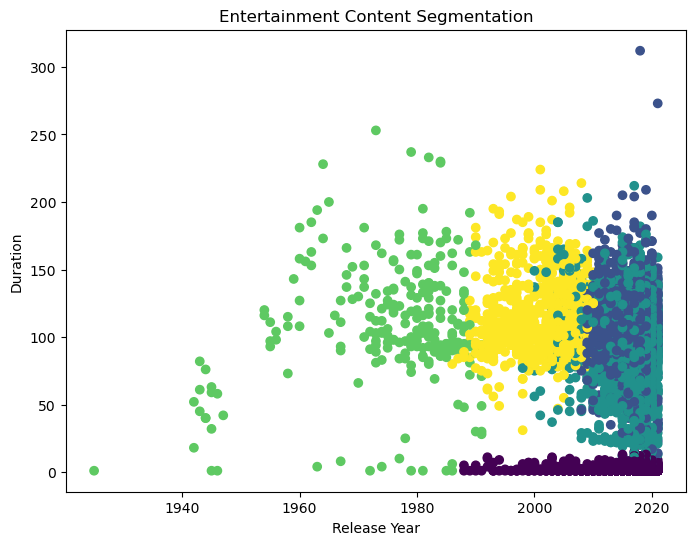

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['release_year'],
    df['duration'],
    c=df['Cluster']
)

plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Entertainment Content Segmentation")
plt.show()

In [24]:
df.groupby('Cluster')[['release_year', 'duration']].mean()

,release_year,duration
Cluster,,
0,2016.842283,1.758543
1,2016.027656,104.040825
2,2016.661938,90.656747
3,1975.910204,109.379592
4,2001.740082,115.528044


In [25]:
df.to_csv("Entertainment_Content_Clusters.csv", index=False)

print("CSV Saved Successfully")

CSV Saved Successfully
